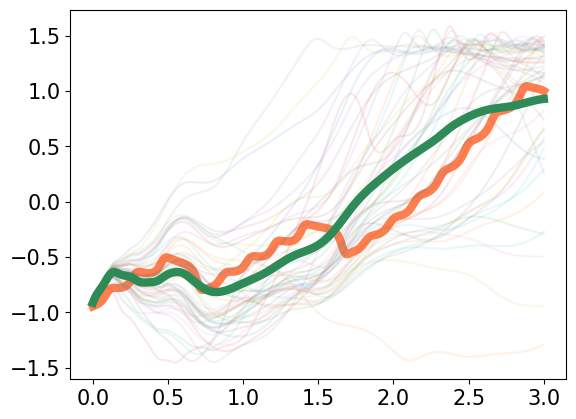

In [1]:
import numpy as np
import networkx as nx
import os.path
import matplotlib.pyplot as plt
import time
import gc
gc.collect()
import warnings
warnings.filterwarnings("ignore")
import os
from scipy.integrate import odeint
os.system('cls' if os.name == 'nt' else 'clear')
plt.rc('font',size=15)

UseDoubleWell=1
RCType=0# Different RC architecture: 0 deterministic RC to learn noise; 1/2 with noise in/out side tanh
dt = 0.01; #steplength
TestLength=300 #00 # Number of points for test/validation phase: 0.01 steplength
T2 =22+TestLength*dt  # Total time length: including training phase and test/validation phase

'''
This code is to do rolling prediction (predicting phase), 
training phase is in code 'RC for deterministic',
reservior for noise is in code 'RC for lorenz noise'.
'''

anoise=[]
atrajectory=np.zeros((1,TestLength+1))
xtimes=np.linspace(0,int(TestLength*dt),TestLength)
start = time.time() 

"""SDE: double well
"""

def f(y, t):  #Odeint, \dot{x}:Doublewell, \dot{y}:Lorenz Noise, and \dot{y_2} is the noise in SDE
    epsilon = 0.5
    sigma = 0.08
    x, y1, y2, y3 = y
    dx_dt = x * (1 - x**2) + (sigma / epsilon) * y2
    dy1_dt = 10 * (y2 - y1) / epsilon**2
    dy2_dt = (28 * y1 - y2 - y1 * y3) / epsilon**2
    dy3_dt = (y1 * y2 - 8/3 * y3) / epsilon**2
    anoise.append(dt * sigma / epsilon*y2)
    return np.array([dx_dt, dy1_dt, dy2_dt, dy3_dt])

    
def DoubleWell():  #Generate data
    global anoise
    t0 = 0
    tf = int(T2)
    x0 = -1.5
    y0 = np.array([x0, 1, 1, 1])
    t = np.arange(t0, tf + dt, dt)
    y = odeint(f, y0, t)
    u = y[:, 0]
    u=u.reshape((1,u.shape[0]))
    plt.clf()
    xtime=np.linspace(t0,tf,u.shape[1])
    #plt.plot(xtime,u[0,:],color='coral',linestyle='-')
    #plt.axvline(23.8,color='forestgreen',linestyle='dashed',linewidth=2)
    #plt.savefig('../results/actual.pdf',bbox_inches='tight',dpi=600)
    #plt.show()
    return u 

class Reservoir:
    def __init__(self,Utotal,hyperparameters):      
        # Input layer
        u=Utotal[0]
        self.NumBifurPara=np.shape(Utotal)[0]       
        self.M = u.shape[0]  
        self.input_len = u.shape[1]
        self.dataset = Utotal

        # Reservoir layer
        self.N = 1000
        self.dimensions = 1
        self.P = u.shape[0]
        self.bias = 0
        
        # Training relevant: have used their ratio of separating the input data
        self.init_len = 0
        self.train_len = np.int(self.input_len-TestLength-1)
        self.test_len = np.int(TestLength)
        self.error_len = np.int(TestLength)
        self.T2=self.input_len
        
        # Hyperparameters to be optimized: here set their initial value of hyperparameters
        self.kin =hyperparameters[0] # uniform distribution of $[-k_{in},k_{in}]$ of W_{in}, W_{b}, W_{\epsilon}
        self.D = hyperparameters[1] # degree of reservoir matrix A ...  #What is the degree function in their code: the degree of the renyi-Erdos network
        self.rho = hyperparameters[2] # spectral radius: rho  -> "appropriately scaled by its largest eigenvalue ρ."
        self.alpha =hyperparameters[3] 
        self.beta = hyperparameters[4] 
        self.parab=0 #set as zero for now, because no para-layer yet
        self.parak=0 #set as zero for now, because no para-layer yet
        self.paraepsilon=0 #epsilon for RC and consistent with SDE model

        
    def train(self,parascanRange): 
        self.Win =np.random.uniform(-self.kin,self.kin, (self.N, self.M + 1))
        self.Wb= np.random.uniform(-self.kin, self.kin, (self.N, 1))
        self.Wxi=np.random.uniform(-self.kin,self.kin, (self.N, self.M))  
        # TODO: the values of non-zero elements are randomly drawn from uniform dist [-1, 1]
        g = nx.erdos_renyi_graph(self.N, self.D / self.N, 42, True)
        self.A = nx.adjacency_matrix(g).todense()
        ## spectral radius: rho  -> "appropriately scaled by its largest eigenvalue ρ."
        self.A = self.A * 1.25/self.rho
        # print(max(abs(np.linalg.eig(self.A)[0])))
        
        # run the reservoir with the data and collect r
        self.rFinalTrainTotal=[]
        for index in range(self.NumBifurPara):
            self.paralayer=parascanRange[index]
            self.R = np.zeros(
                    (1 + self.N + self.M, self.train_len-self.init_len ))
                # collection of input signals
            self.S = np.vstack((x[self.init_len + 1: self.train_len + 1] for x in self.dataset[index])) # make multi-dimensional input data from training window
            self.r = np.zeros((self.N, 1))
            for t in range(self.train_len):
                V = np.vstack((x[t] for x in self.dataset[index]))
                Xi= np.random.normal(0,1, (self.M, 1))#Gaussian white noise
                if RCType==0:
                    #RC0: 0 deterministic RC to learn noise
                    self.r = (1 - self.alpha) * self.r + self.alpha * np.tanh(np.dot(self.A,self.r) 
                          + np.dot(self.Win, np.vstack((self.bias, V)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                if RCType==1:
                    #RC1: noise inside tanh
                    self.r = (1 - self.alpha) * self.r + self.alpha * np.tanh(np.dot(self.A,self.r) 
                          + np.dot(self.Win, np.vstack((self.bias, V)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab)
                          + np.sqrt(self.paraepsilon)*np.dot(self.Wxi,Xi))            
                if RCType==2:
                    #RC2: noise outside tanh
                    self.r = (1 - self.alpha) * self.r + self.alpha * (np.tanh(np.dot(self.A,self.r) 
                         + np.dot(self.Win, np.vstack((self.bias, V)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                         + np.sqrt(self.paraepsilon)*np.dot(self.Wxi,Xi)) 
                if t >= self.init_len:
                    self.R[:, [t - self.init_len]
                           ] = np.vstack((self.bias, V, self.r))[:, 0]
            if index==0:
                self.RTotal=self.R
                self.STotal=self.S             
            else:            
                self.RTotal=np.append(self.RTotal,self.R, axis=1)
                self.STotal=np.append(self.STotal,self.S, axis=1)
            self.rFinalTrainTotal.append(self.r[:,-1])#    self.RFinalTrainTotal=np.append(self.RFinalTrainTotal,self.R[:,-1])

        # train the output
        R = self.RTotal  # Transpose
        R_T=R.T 
        self.Wout = np.dot(np.dot(self.STotal, R_T), np.linalg.inv(
            np.dot(self.RTotal, R_T) + self.beta * np.eye(self.M + self.N + 1)))
        return self.Wout

    def train2(self,WoutPara):
        # use $W_{out}$ to get the deviation to approximate the noise distribution.
        global t
        self.SampledNoise = []
        for index in range(self.NumBifurPara):
            self.paralayer=parascanRange[index]
            self.R = np.zeros(
                    (1 + self.N + self.M, self.train_len - self.init_len))
            self.S = np.vstack((x[self.init_len + 1: self.train_len + 1] for x in self.dataset[index])) # make multi-dimensional input data from training window
            self.r = np.zeros((self.N, 1))
            for t in range(self.train_len):
                V = np.vstack((x[t] for x in self.dataset[index]))   
                
                #RC0: 0 deterministic RC to learn noise
                self.r = (1 - self.alpha) * self.r + self.alpha * np.tanh(np.dot(self.A,self.r) 
                          + np.dot(self.Win, np.vstack((self.bias, V)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                s = np.dot(WoutPara, np.vstack((self.bias, V, self.r)))

                self.S[:, t] = np.squeeze(np.asarray(s))               

            for i in range(self.dimensions):

              X=self.dataset[index][np.array(range(int(self.P/self.dimensions)))*self.dimensions+i, 1: self.train_len + 1]
              Y=self.S[np.array(range(int(self.P/self.dimensions)))*self.dimensions+i, 0: self.train_len ] ####    #self.dataset[range(self.P)*self.dimensions+i, self.train_len+1: self.train_len+self.error_len+1]
              SampledNoise=[]

              for j in range(X.shape[1]):
                  XX=np.array(X[:,j])  
                  YY=np.array(Y[:,j])
                  NoiseTemp=XX-YY
                  Bins=max(5,int(np.sqrt(X.shape[0])))
                  hist, bins = np.histogram(NoiseTemp, bins=Bins,range=(min(NoiseTemp),max(NoiseTemp)), density=True)#np.histogram(data, bins=50)
                  bin_midpoints = bins[:-1] + np.diff(bins)/2
                  cdf = np.cumsum(hist)
                  cdf = cdf / cdf[-1]
                  values = np.random.rand(X.shape[0])
                  value_bins = np.searchsorted(cdf, values)
                  random_from_cdf = bin_midpoints[value_bins]
                  if j<0:#show the fitting to the noise distribution
                        plt.subplot(121)
                        plt.hist(NoiseTemp, Bins)
                        plt.subplot(122)
                        plt.hist(random_from_cdf, Bins)
                        plt.show()
                  
                  SampledNoise.append(random_from_cdf)
              self.SampledNoise.append(SampledNoise) 

    def _run(self,WoutPara,Load,i):
        if Load==0:
            np.save(r'../data/1d bistable system with colored noise/Win.npy',self.Win)
            np.save(r'../data/1d bistable system with colored noise/A.npy',self.A)
            np.save(r'../data/1d bistable system with colored noise/WoutPara.npy',WoutPara)
            np.save(r'../data/1d bistable system with colored noise/Wb.npy',self.Wb)
            np.save(r'../data/1d bistable system with colored noise/Wxi.npy',self.Wxi)
            np.save(r'../data/1d bistable system with colored noise/r.npy',self.rFinalTrainTotal)
            
        else:
         
            self.Win = np.load(os.path.join(data_dir, '1d bistable system with colored noise', 'Win.npy'))
            self.A = np.load(os.path.join(data_dir, '1d bistable system with colored noise', 'A.npy'))
            WoutPara = np.load(os.path.join(data_dir, '1d bistable system with colored noise', 'WoutPara.npy'))
            self.Wb = np.load(os.path.join(data_dir, '1d bistable system with colored noise', 'Wb.npy'))
            self.Wxi = np.load(os.path.join(data_dir, '1d bistable system with colored noise', 'Wxi.npy'))
            self.rFinalTrainTotal = np.load(os.path.join(data_dir, '1d bistable system with colored noise', 'r.npy'))

        
        self.S = np.zeros((self.P, self.test_len))
        self.S_1 = np.zeros((self.P, self.test_len))
        self.S_2 = np.zeros((self.P, self.test_len))
        self.S_3 = np.zeros((self.P, self.test_len))
        self.S_4 = np.zeros((self.P, self.test_len))
        self.S_5 = np.zeros((self.P, self.test_len))
        self.S_6 = np.zeros((self.P, self.test_len))
        self.S_7 = np.zeros((self.P, self.test_len))
        self.S_8 = np.zeros((self.P, self.test_len))
        self.S_9 = np.zeros((self.P, self.test_len))
        
        for index in range(self.NumBifurPara):
            V = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_1 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_2 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_3 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_4 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_5 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_6 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_7 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_8 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            V_9 = np.vstack((x[self.train_len] for x in self.dataset[index]))
            
            # V[:,0]=0
            if Load == 0:
                V[:,0]=0
                V_1[:,0] =1.5
                V_2[:,0]=0.5
                V_3[:,0]=-0.5
                V_4[:,0]=-1.5
                V_5[:,0]=0.75
                V_6[:,0]=-0.75
                V_7[:,0]=1.25
                V_8[:,0]=-1.25
                V_9[:,0]=0
                        

            if Load == 0:
                self.r=self.rFinalTrainTotal[index]
                self.r_1=self.rFinalTrainTotal[index]
                self.r_2=self.rFinalTrainTotal[index]
                self.r_3=self.rFinalTrainTotal[index]
                self.r_4=self.rFinalTrainTotal[index]
                self.r_5=self.rFinalTrainTotal[index]
                self.r_6=self.rFinalTrainTotal[index]
                self.r_7=self.rFinalTrainTotal[index]
                self.r_8=self.rFinalTrainTotal[index]
                self.r_9=self.rFinalTrainTotal[index]
            else:
                self.r=self.rFinalTrainTotal[index]
            
            if RCType==0:
                
                global NoiseToUse
                NoiseToUse=np.array(self.SampledNoise)
                unique_elements, counts = np.unique(NoiseToUse, return_counts=True)
                probabilities = counts / np.sum(counts)
            for t in range(self.test_len):
                # r(t + \Delta t) = (1 - alpha)r(t) + alpha * tanh(A * r(t) + Win * V(t) + bias)
                if RCType==0:
                     self.r = (1 - self.alpha) * self.r + self.alpha * np.tanh(np.dot(self.A,self.r) 
                              + np.dot(self.Win, np.vstack((self.bias, V)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                    
                     if Load == 0:
                    #RC0: 0 deterministic RC to learn noise
                       
                        self.r_1 = (1 - self.alpha) * self.r_1 + self.alpha * np.tanh(np.dot(self.A,self.r_1) 
                              + np.dot(self.Win, np.vstack((self.bias, V_1)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                              
                        self.r_2 = (1 - self.alpha) * self.r_2 + self.alpha * np.tanh(np.dot(self.A,self.r_2) 
                              + np.dot(self.Win, np.vstack((self.bias, V_2)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                              
                        self.r_3 = (1 - self.alpha) * self.r_3 + self.alpha * np.tanh(np.dot(self.A,self.r_3) 
                              + np.dot(self.Win, np.vstack((self.bias, V_3)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                        
                        self.r_4 = (1 - self.alpha) * self.r_4 + self.alpha * np.tanh(np.dot(self.A,self.r_4) 
                              + np.dot(self.Win, np.vstack((self.bias, V_4)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                        
                        self.r_5 = (1 - self.alpha) * self.r_5 + self.alpha * np.tanh(np.dot(self.A,self.r_5) 
                              + np.dot(self.Win, np.vstack((self.bias, V_5)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                        
                        self.r_6 = (1 - self.alpha) * self.r_6 + self.alpha * np.tanh(np.dot(self.A,self.r_6) 
                              + np.dot(self.Win, np.vstack((self.bias, V_6)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                        
                        self.r_7 = (1 - self.alpha) * self.r_7 + self.alpha * np.tanh(np.dot(self.A,self.r_7) 
                              + np.dot(self.Win, np.vstack((self.bias, V_7)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                        
                        self.r_8 = (1 - self.alpha) * self.r_8 + self.alpha * np.tanh(np.dot(self.A,self.r_8) 
                              + np.dot(self.Win, np.vstack((self.bias, V_8)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                        
                        self.r_9 = (1 - self.alpha) * self.r_9 + self.alpha * np.tanh(np.dot(self.A,self.r_9) 
                              + np.dot(self.Win, np.vstack((self.bias, V_9)))+self.parak*np.dot(self.Wb, self.paralayer+self.parab))
                   
                        
                
                if np.isnan(np.sum(np.sum(np.array(self.r)))):
                    print('R')
                    print(np.max(V))
                    print(np.max(np.max(WoutPara)),np.min(np.min(WoutPara)))
                
                s = np.dot(WoutPara, np.vstack((self.bias, V, self.r)))     
                if Load ==0:
                    
                    s_1 = np.dot(WoutPara, np.vstack((self.bias, V_1, self.r_1)))
                    s_2 = np.dot(WoutPara, np.vstack((self.bias, V_2, self.r_2)))
                    s_3 = np.dot(WoutPara, np.vstack((self.bias, V_3, self.r_3)))
                    s_4 = np.dot(WoutPara, np.vstack((self.bias, V_4, self.r_4)))
                    s_5 = np.dot(WoutPara, np.vstack((self.bias, V_5, self.r_5)))
                    s_6 = np.dot(WoutPara, np.vstack((self.bias, V_6, self.r_6)))
                    s_7 = np.dot(WoutPara, np.vstack((self.bias, V_7, self.r_7)))
                    s_8 = np.dot(WoutPara, np.vstack((self.bias, V_8, self.r_8)))
                    s_9 = np.dot(WoutPara, np.vstack((self.bias, V_9, self.r_9)))
                
                self.S[:, t] = np.squeeze(np.asarray(s))
                if Load ==0:
                    self.S_1[:, t] = np.squeeze(np.asarray(s_1))
                    self.S_2[:, t] = np.squeeze(np.asarray(s_2))
                    self.S_3[:, t] = np.squeeze(np.asarray(s_3))
                    self.S_4[:, t] = np.squeeze(np.asarray(s_4))
                    self.S_5[:, t] = np.squeeze(np.asarray(s_5))
                    self.S_6[:, t] = np.squeeze(np.asarray(s_6))
                    self.S_7[:, t] = np.squeeze(np.asarray(s_7))
                    self.S_8[:, t] = np.squeeze(np.asarray(s_8))
                    self.S_9[:, t] = np.squeeze(np.asarray(s_9))
                
                              
                if RCType==0:
                   
                    self.S[:, t] = self.S[:, t]
                    if Load ==0:
                        self.S_1[:, t] = self.S_1[:, t]
                        self.S_2[:, t] = self.S_2[:, t]
                        self.S_3[:, t] = self.S_3[:, t]
                        self.S_4[:, t] = self.S_4[:, t]
                        self.S_5[:, t] = self.S_5[:, t]
                        self.S_6[:, t] = self.S_6[:, t]
                        self.S_7[:, t] = self.S_7[:, t]
                        self.S_8[:, t] = self.S_8[:, t]
                        self.S_9[:, t] = self.S_9[:, t]
                    
                if Load == 0:
                    V = s
                    V_1= s_1 
                    V_2 = s_2
                    V_3 = s_3
                    V_4 = s_4
                    V_5 = s_5
                    V_6 = s_6
                    V_7 = s_7
                    V_8 = s_8
                    V_9 = s_9
                else:
                    V = s+NoiseTotal[i,t]
            
            if Load == 0:
                x = np.linspace(0,self.test_len*dt,self.test_len)
                plt.axhline(1,linestyle='--',color='navy',alpha=0.5)
                plt.axhline(-1,linestyle='--',color='navy',alpha=0.5)
                plt.ylabel('$u_1$')
                plt.plot(x,self.S[0,:],color='red',linewidth=1,linestyle='-') 
                plt.plot(x,self.S_1[0,:],color='blue',linewidth=1,linestyle='-')
                plt.plot(x,self.S_2[0,:],color='green',linewidth=1,linestyle='-')
                plt.plot(x,self.S_3[0,:],color='black',linewidth=1,linestyle='-')
                plt.plot(x,self.S_4[0,:],color='grey',linewidth=1,linestyle='-')
                plt.plot(x,self.S_5[0,:],color='yellow',linewidth=1,linestyle='-')
                plt.plot(x,self.S_6[0,:],color='pink',linewidth=1,linestyle='-')
                plt.plot(x,self.S_7[0,:],color='purple',linewidth=1,linestyle='-')
                plt.plot(x,self.S_8[0,:],color='orange',linewidth=1,linestyle='-')
                plt.plot(x,self.S_9[0,:],color='brown',linewidth=1,linestyle='-')
                plt.xlim(0,10)
                # plt.savefig('deterministic.pdf',bbox_inches = 'tight',dpi=600)
                plt.show()
                
            else:

                x = np.linspace(0,self.test_len*dt,self.test_len)
                dataset=np.array(self.dataset).flatten()
                #atrajectory[0,:]=dataset[self.train_len:]
                # np.save('actualTrajectory.npy',atrajectory)
                #plt.plot(dataset[self.train_len:],color='coral',linestyle='-')
                plt.plot(self.S[0,:],color='seagreen',linewidth=1,linestyle='-') 
                # plt.savefig('ptra.pdf',bbox_inches = 'tight')
                # plt.show()
                TrajectoryTotal[i,:]=self.S[0,:]


def GenerateEnsemble(Realizations):
    for j in range(Realizations):
        uTemp=DoubleWell() 
        if j==0:
            u=uTemp
        else:
            u=np.vstack((u, uTemp))
    return u
         
if __name__ == '__main__':
    
    if UseDoubleWell==1:
 
        current_path = os.getcwd()
        base_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_path)))
        data_dir = os.path.join(base_dir, 'data')
        NoiseTotal = np.load(os.path.join(data_dir, '1d bistable system with colored noise','NoiseTotal.npy'))

        L=np.shape(NoiseTotal)[0]
        TrajectoryTotal=np.zeros(np.shape(NoiseTotal))
        for i in range (L):
            Realizations=1#00
        
            parascanRange=[0.2]
            BinNumber=4
            Utotal=[]

            Load=1  #In this code, we always make Load = 1, Load = 0 should play in code 'RC for deterministic'.
            
            rcpara=np.zeros(5)  # hyperparameters for RC
            rcpara[0]=1.5  #K_{in}
            rcpara[1]=3.2  #D
            rcpara[2]=3000 #relevant to rho: rho=0.0013
            rcpara[3]=0.25 #alpha
            rcpara[4]=1e-7 #beta
            
            paraTest=parascanRange[0]

            Utotal=[]
            u=GenerateEnsemble(Realizations)
            Utotal.append(u)
            r2 = Reservoir(Utotal,rcpara)
            WoutTempReal = r2.train([paraTest])
            if RCType==0:
                    r2.train2(WoutTempReal)
            r2._run(WoutTempReal,Load,i)
        plt.clf()
        TrajectoryAvg=np.mean(TrajectoryTotal,axis=0)
        TrajectoryAvg=TrajectoryAvg.reshape(1,-1)
        # np.save('totalTrajectory.npy',TrajectoryTotal)
        # np.save('avgTrajectory.npy',TrajectoryAvg)
        atrajectory = np.load(os.path.join(data_dir, '1d bistable system with colored noise','actualTrajectory.npy'))

        plt.plot(xtimes,atrajectory[0,:TestLength],color='coral',linestyle='-',linewidth=6)
        for i in range(L):
            plt.plot(xtimes,TrajectoryTotal[i,:],alpha=0.1,linestyle='-')
        plt.plot(xtimes,TrajectoryAvg[0,:],color='seagreen',linestyle='-',linewidth=6)
        # plt.savefig('../results/Total.pdf',bbox_inches='tight',dpi=600)
        plt.show()

